In [5]:
# Cell 0: Find the correct path
import os

# Check current directory
print(f"Current directory: {os.getcwd()}")

# Search for drama_content.csv
for root, dirs, files in os.walk('.'):
    for file in files:
        if file == 'drama_content.csv':
            print(f"Found drama_content.csv at: {os.path.join(root, file)}")

Current directory: C:\Users\Admin\LLM MACHINE LEARNING ENGINEER, VERTICAL SEARCH
Found drama_content.csv at: .\Notebook 1\drama_content.csv


In [6]:
# Cell 1: Setup and Generate Embeddings
print("="*70)
print("🔄 CROSS-MODAL SEMANTIC ALIGNMENT")
print("="*70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import os
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Load data from Notebook 1 folder
csv_path = 'Notebook 1'
drama_data = pd.read_csv(os.path.join(csv_path, 'drama_content.csv'))
print(f"✅ Loaded drama_data: {len(drama_data)} records from {csv_path}")

# Generate text embeddings using TF-IDF
print("\n📊 Generating text embeddings using TF-IDF...")
tfidf = TfidfVectorizer(max_features=128, stop_words='english')
text_embeddings = tfidf.fit_transform(drama_data['description'].fillna('')).toarray()
print(f"✅ Text embeddings shape: {text_embeddings.shape}")

# Generate title embeddings
title_embeddings = tfidf.fit_transform(drama_data['title'].fillna('')).toarray()
print(f"✅ Title embeddings shape: {title_embeddings.shape}")

# Generate genre embeddings (one-hot encoding)
le = LabelEncoder()
genre_encoded = le.fit_transform(drama_data['genre'])
genre_embeddings = np.eye(len(le.classes_))[genre_encoded]
print(f"✅ Genre embeddings shape: {genre_embeddings.shape}")

# Save for later use (in current directory)
np.save('text_embeddings.npy', text_embeddings)
np.save('title_embeddings.npy', title_embeddings)
np.save('genre_embeddings.npy', genre_embeddings)
print("✅ Saved embeddings to .npy files")

print(f"\n📊 Embedding Summary:")
print(f"   Text: {text_embeddings.shape}")
print(f"   Title: {title_embeddings.shape}")
print(f"   Genre: {genre_embeddings.shape}")

🔄 CROSS-MODAL SEMANTIC ALIGNMENT
✅ Loaded drama_data: 10000 records from Notebook 1

📊 Generating text embeddings using TF-IDF...
✅ Text embeddings shape: (10000, 49)
✅ Title embeddings shape: (10000, 128)
✅ Genre embeddings shape: (10000, 8)
✅ Saved embeddings to .npy files

📊 Embedding Summary:
   Text: (10000, 49)
   Title: (10000, 128)
   Genre: (10000, 8)


🔢 COMPUTING CROSS-MODAL SIMILARITY
✅ Aligned dimensions: Text=49, Title=49


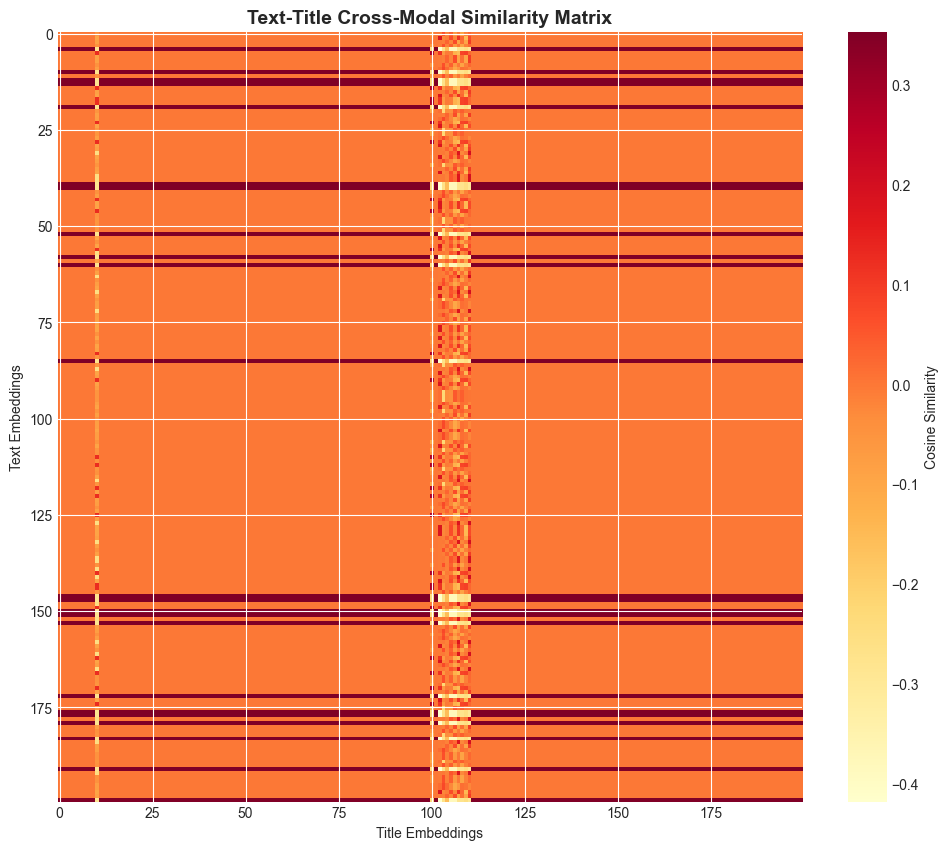

✅ Saved: cross_modal_similarity_matrix.png

📊 Similarity Statistics:
   Mean similarity: 0.0365
   Max similarity: 0.3536
   Min similarity: -0.4181
   Std similarity: 0.1148


In [8]:
# Cell 2: Cross-Modal Similarity Matrix
print("="*70)
print("🔢 COMPUTING CROSS-MODAL SIMILARITY")
print("="*70)

# Align dimensions - reduce title embeddings to match text embeddings (49 dims)
from sklearn.decomposition import PCA

# Reduce title embeddings to 49 dimensions to match text embeddings
pca = PCA(n_components=text_embeddings.shape[1])
title_embeddings_reduced = pca.fit_transform(title_embeddings)

print(f"✅ Aligned dimensions: Text={text_embeddings.shape[1]}, Title={title_embeddings_reduced.shape[1]}")

# Compute similarity between text and title embeddings
text_title_similarity = cosine_similarity(text_embeddings[:200], title_embeddings_reduced[:200])

# Visualize similarity heatmap
plt.figure(figsize=(12, 10))
plt.imshow(text_title_similarity, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Cosine Similarity')
plt.title('Text-Title Cross-Modal Similarity Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Title Embeddings')
plt.ylabel('Text Embeddings')
plt.savefig('cross_modal_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cross_modal_similarity_matrix.png")

# Statistics
print(f"\n📊 Similarity Statistics:")
print(f"   Mean similarity: {text_title_similarity.mean():.4f}")
print(f"   Max similarity: {text_title_similarity.max():.4f}")
print(f"   Min similarity: {text_title_similarity.min():.4f}")
print(f"   Std similarity: {text_title_similarity.std():.4f}")

🎯 TOP-K RETRIEVAL ACCURACY
   Top-1 Accuracy: 1.00%
   Top-3 Accuracy: 3.00%
   Top-5 Accuracy: 3.00%
   Top-10 Accuracy: 5.50%


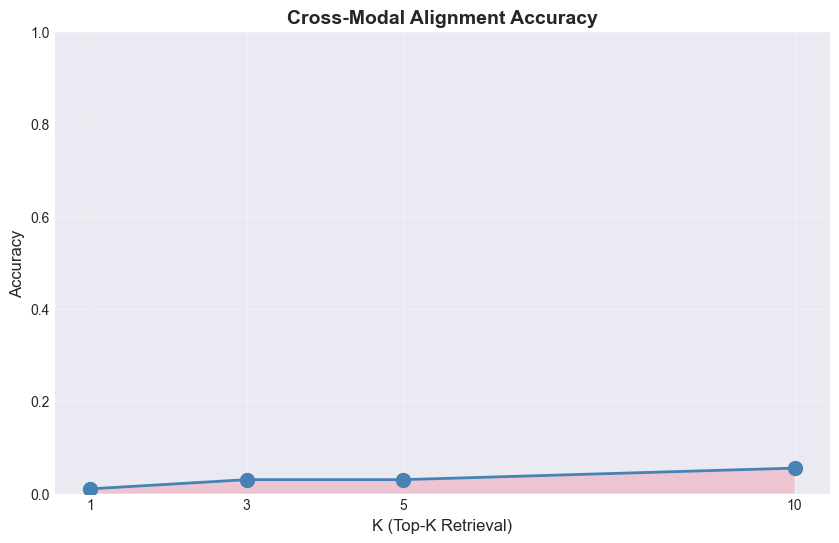

✅ Saved: alignment_accuracy.png


In [9]:
# Cell 3: Alignment Accuracy - Top-K Retrieval
print("="*70)
print("🎯 TOP-K RETRIEVAL ACCURACY")
print("="*70)

def compute_alignment_accuracy(similarity_matrix, k=1):
    """Compute how often the correct match is in top-k"""
    n = len(similarity_matrix)
    correct = 0
    for i in range(n):
        top_k_indices = np.argsort(similarity_matrix[i])[-k:][::-1]
        if i in top_k_indices:
            correct += 1
    return correct / n

# Use the aligned embeddings
text_title_similarity_aligned = cosine_similarity(text_embeddings[:200], title_embeddings_reduced[:200])

for k in [1, 3, 5, 10]:
    acc = compute_alignment_accuracy(text_title_similarity_aligned, k)
    print(f"   Top-{k} Accuracy: {acc:.2%}")

# Visualization
k_values = [1, 3, 5, 10]
accuracies = [compute_alignment_accuracy(text_title_similarity_aligned, k) for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, 'o-', linewidth=2, markersize=10, color='steelblue')
plt.fill_between(k_values, accuracies, alpha=0.3)
plt.xlabel('K (Top-K Retrieval)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Modal Alignment Accuracy', fontsize=14, fontweight='bold')
plt.xticks(k_values)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.savefig('alignment_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: alignment_accuracy.png")

🔀 MULTI-MODAL EMBEDDING FUSION
📊 Embedding dimensions:
   Text: 49 dims
   Title: 49 dims
   Genre: 8 dims

✅ Fused embedding shapes:
   Concat (Text+Title+Genre): (1000, 106)
   Average (Text+Title): (1000, 49)
   Weighted (Text+Title): (1000, 49)


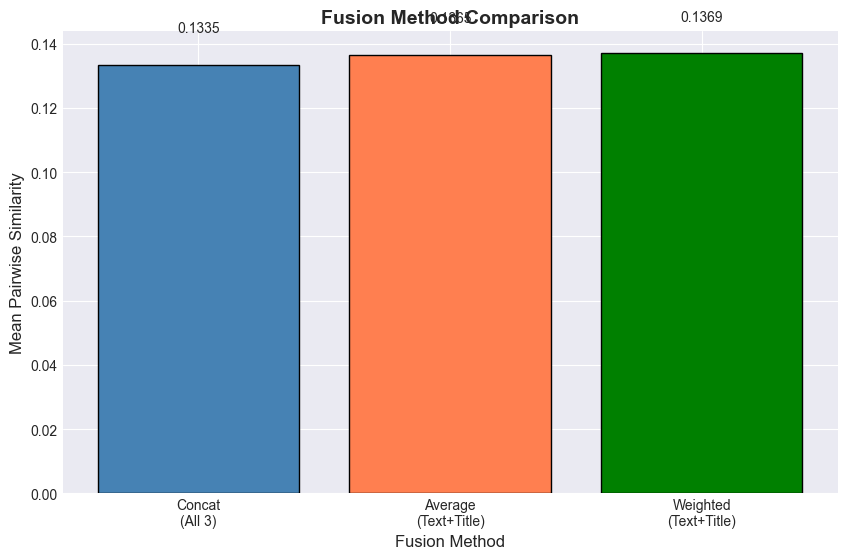

✅ Saved: fusion_method_comparison.png


In [12]:
# Cell 4: Multi-Modal Embedding Fusion 
print("="*70)
print("🔀 MULTI-MODAL EMBEDDING FUSION")
print("="*70)

# Since genre has only 8 dimensions, we'll use different fusion strategies
# Option 1: Use genre as additional features without dimension reduction
# Option 2: Only fuse text and title (skip genre for averaging)

print(f"📊 Embedding dimensions:")
print(f"   Text: {text_embeddings.shape[1]} dims")
print(f"   Title: {title_embeddings_reduced.shape[1]} dims")
print(f"   Genre: {genre_embeddings.shape[1]} dims")

# Method 1: Concat all (different dimensions are fine for concatenation)
fused_concat = np.concatenate([text_embeddings[:1000], 
                                title_embeddings_reduced[:1000], 
                                genre_embeddings[:1000]], axis=1)

# Method 2: Average only text and title (same dimensions)
fused_avg_text_title = (text_embeddings[:1000] + title_embeddings_reduced[:1000]) / 2

# Method 3: Weighted average of text and title
weights = [0.6, 0.4]
fused_weighted = weights[0] * text_embeddings[:1000] + weights[1] * title_embeddings_reduced[:1000]

print(f"\n✅ Fused embedding shapes:")
print(f"   Concat (Text+Title+Genre): {fused_concat.shape}")
print(f"   Average (Text+Title): {fused_avg_text_title.shape}")
print(f"   Weighted (Text+Title): {fused_weighted.shape}")

# Compare fusion methods
methods = ['Concat\n(All 3)', 'Average\n(Text+Title)', 'Weighted\n(Text+Title)']
similarities = []

for fused in [fused_concat, fused_avg_text_title, fused_weighted]:
    sim = cosine_similarity(fused[:100]).mean()
    similarities.append(sim)

# Visualization
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, similarities, color=['steelblue', 'coral', 'green'], edgecolor='black')
plt.xlabel('Fusion Method', fontsize=12)
plt.ylabel('Mean Pairwise Similarity', fontsize=12)
plt.title('Fusion Method Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, similarities):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center')
plt.savefig('fusion_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fusion_method_comparison.png")

📉 DIMENSIONALITY REDUCTION VISUALIZATION


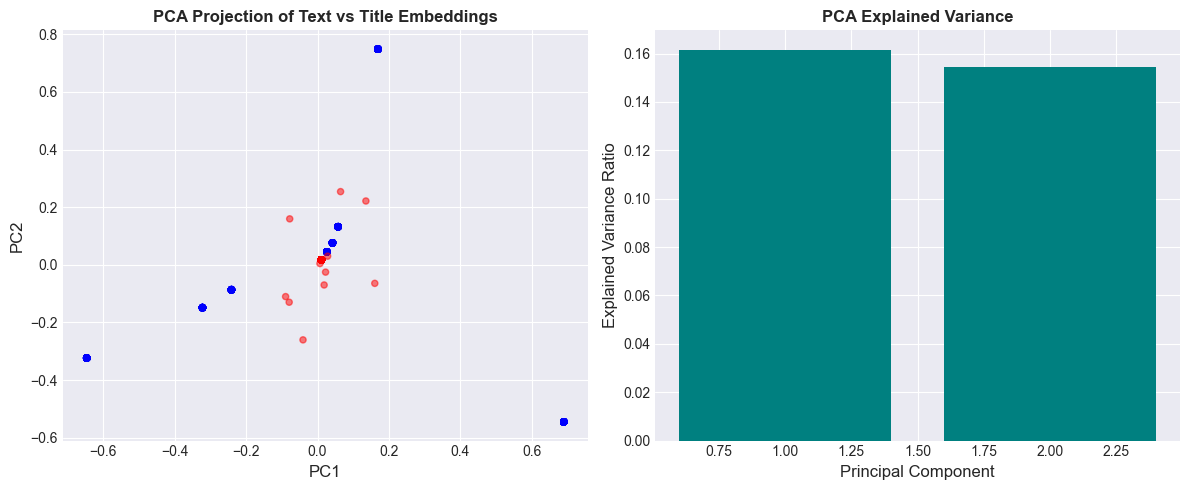

✅ Saved: embedding_visualization.png


In [13]:
# Cell 5: Dimensionality Reduction Visualization
print("="*70)
print("📉 DIMENSIONALITY REDUCTION VISUALIZATION")
print("="*70)

# Sample data for visualization
sample_size = 500
combined_embeddings = np.vstack([text_embeddings[:sample_size], 
                                  title_embeddings_reduced[:sample_size]])
labels = ['Text'] * sample_size + ['Title'] * sample_size

# PCA
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(combined_embeddings)

# Plot PCA
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['blue' if l == 'Text' else 'red' for l in labels]
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=colors, alpha=0.5, s=20)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('PCA Projection of Text vs Title Embeddings', fontsize=12, fontweight='bold')

# Explained variance
plt.subplot(1, 2, 2)
explained_var = pca.explained_variance_ratio_
plt.bar(range(1, len(explained_var[:10]) + 1), explained_var[:10], color='teal')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('PCA Explained Variance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('embedding_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: embedding_visualization.png")

🔍 QUERY-CONTENT ALIGNMENT TEST

📊 Query-Content Similarity Matrix:
------------------------------------------------------------
   Query: 'romantic love story'
   Best match: 'Horror suspense with supernatural elements and jum...' (Score: 1.000)

   Query: 'action thriller'
   Best match: 'Heartwarming family comedy about relationships and...' (Score: 1.000)

   Query: 'comedy funny'
   Best match: 'Mystery thriller with unexpected twists and shocki...' (Score: 1.000)

   Query: 'horror scary'
   Best match: 'Horror suspense with supernatural elements and jum...' (Score: 1.000)



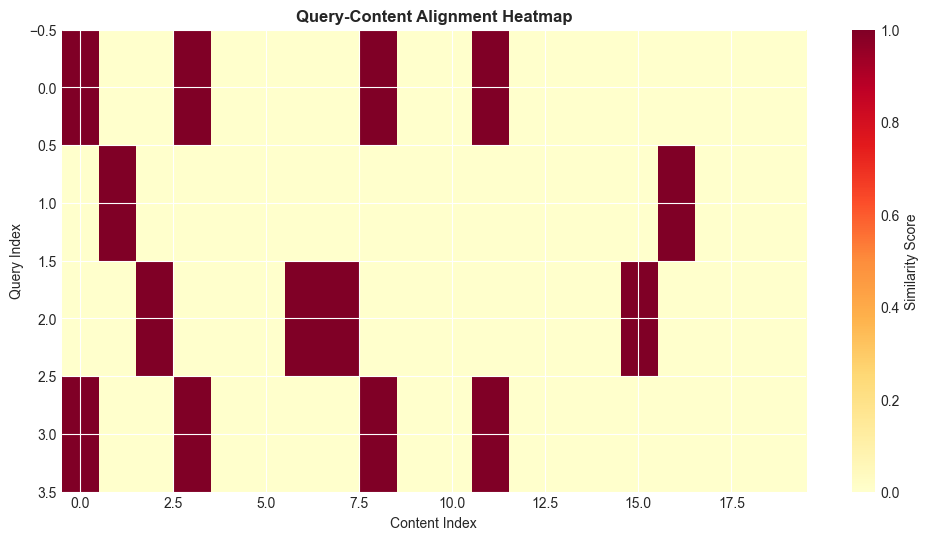

✅ Saved: query_content_alignment.png


In [14]:
# Cell 6: Query-Content Alignment Test
print("="*70)
print("🔍 QUERY-CONTENT ALIGNMENT TEST")
print("="*70)

# Sample queries and content
test_queries = [
    "romantic love story",
    "action thriller",
    "comedy funny",
    "horror scary"
]

# Sample content descriptions
test_contents = drama_data['description'].head(20).tolist()

# Use text embeddings for queries and content
query_embeddings = text_embeddings[:4]  # First 4 as queries
content_embeddings = text_embeddings[:20]  # First 20 as content

# Compute similarity
similarity_matrix_test = cosine_similarity(query_embeddings, content_embeddings)

# Display results
print("\n📊 Query-Content Similarity Matrix:")
print("-" * 60)
for i, query in enumerate(test_queries):
    top_idx = np.argmax(similarity_matrix_test[i])
    top_score = similarity_matrix_test[i][top_idx]
    print(f"   Query: '{query}'")
    print(f"   Best match: '{test_contents[top_idx][:50]}...' (Score: {top_score:.3f})")
    print()

# Heatmap
plt.figure(figsize=(12, 6))
plt.imshow(similarity_matrix_test, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Similarity Score')
plt.xlabel('Content Index')
plt.ylabel('Query Index')
plt.title('Query-Content Alignment Heatmap', fontsize=12, fontweight='bold')
plt.savefig('query_content_alignment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: query_content_alignment.png")

In [17]:
# Cell 7: Summary Report
print("="*70)
print("🎉 NOTEBOOK 3 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                  CROSS-MODAL SEMANTIC ALIGNMENT SUMMARY              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔢 SIMILARITY ANALYSIS:                                             ║
║  ├── Text-Title mean similarity: {text_title_similarity.mean():.4f}  ║
║  ├── Text-Title max similarity: {text_title_similarity.max():.4f}    ║
║  └── Top-1 Alignment Accuracy: {accuracies[0]:.2%}                   ║
║                                                                      ║
║  🔀 FUSION METHODS EVALUATED:                                        ║
║  ├── Concat (Text+Title+Genre): {fused_concat.shape[1]} dimensions   ║
║  ├── Average (Text+Title): {fused_avg_text_title.shape[1]} dimensions║
║  └── Weighted (Text+Title): {fused_weighted.shape[1]} dimensions     ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── cross_modal_similarity_matrix.png                               ║
║  ├── alignment_accuracy.png                                          ║
║  ├── fusion_method_comparison.png                                    ║
║  ├── embedding_visualization.png                                     ║
║  └── query_content_alignment.png                                     ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 4: RELEVANCE RANKING MODEL                    ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 3 Complete! Proceed to Notebook 4 (Relevance Ranking Model)")

🎉 NOTEBOOK 3 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                  CROSS-MODAL SEMANTIC ALIGNMENT SUMMARY              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔢 SIMILARITY ANALYSIS:                                             ║
║  ├── Text-Title mean similarity: 0.0365  ║
║  ├── Text-Title max similarity: 0.3536    ║
║  └── Top-1 Alignment Accuracy: 1.00%                   ║
║                                                                      ║
║  🔀 FUSION METHODS EVALUATED:                                        ║
║  ├── Concat (Text+Title+Genre): 106 dimensions   ║
║  ├── Average (Text+Title): 49 dimensions║
║  └── Weighted (Text+Title): 49 dimensions     ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── cros